# Model Comparison and Selection

This notebook records how the model behind the API was chosen. It imports the
same functions that `make train` runs, so the results here cannot drift from the
deployed pipeline.

The target is house price of unit area, measured in 10,000 New Taiwan Dollars
per ping (1 ping = 3.3 m2). All RMSE and MAE figures are in those units.

The order of work is: establish a baseline, fit the simplest real model, add
features that the EDA gives a reason for, test regularization, compare against
two nonlinear models, select, then evaluate once on the holdout.

In [1]:
import joblib
import numpy as np
import pandas as pd
from IPython.display import Image, display
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LassoCV, LinearRegression, RidgeCV
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from house_prices import config
from house_prices.data import load_dataset
from house_prices.evaluate import evaluate
from house_prices.features import FeatureEngineer
from house_prices.train import (
    SCORING,
    Candidate,
    default_candidates,
    run_cv_comparison,
    run_date_ablation,
    select_model,
    split_data,
    train_and_persist,
)

METRICS = ["cv_rmse", "cv_rmse_std", "cv_mae", "cv_r2"]

df = load_dataset()
X_train, X_test, y_train, y_test = split_data(df)
print(f"{len(df)} rows total, {len(X_train)} training, {len(X_test)} holdout")

414 rows total, 331 training, 83 holdout


## 1. Experimental protocol

The 414 observations are split once into 331 training rows and 83 holdout rows,
with a fixed seed so the split is identical on every run.

All model and feature decisions in sections 2 to 5 are made on the 331 training
rows using 5-fold cross-validation. Every candidate is scored on the same folds,
so the numbers are comparable.

The holdout is not used for model or feature selection. It is evaluated once,
after the final model has been chosen, in section 6.

Every candidate is a scikit-learn `Pipeline` holding the feature transforms and
the estimator together. Because the transforms are fitted inside the pipeline,
each cross-validation fold derives them from its own training rows only.

## 2. Mean baseline

The mean predictor ignores every feature and returns the training mean. It
establishes the minimum useful performance: a real model should clearly
outperform always predicting the training mean.

In [2]:
baseline = [c for c in default_candidates() if c.name == "mean_baseline"]
run_cv_comparison(X_train, y_train, baseline)[["model", *METRICS]].round(3)

,model,cv_rmse,cv_rmse_std,cv_mae,cv_r2
0,mean_baseline,13.642,1.935,10.704,-0.026


CV RMSE 13.64, CV MAE 10.70, CV R2 approximately zero. R2 is defined by
comparison with this model, so a mean predictor scores near zero by
construction. The small negative value comes from the mean being computed on
each training fold and scored on a different fold.

## 3. Plain linear regression

Linear regression is the first real model. It is simple, its coefficients can be
read directly, it is cheap to retrain and serve, and it is the model the course
material covers in most depth. That makes it a useful benchmark to establish
before introducing anything more flexible.

It is fitted here on the six raw columns, with no engineered features.

In [3]:
plain = [c for c in default_candidates() if c.name == "linear_regression"]
run_cv_comparison(X_train, y_train, plain)[["model", *METRICS]].round(3)

,model,cv_rmse,cv_rmse_std,cv_mae,cv_r2
0,linear_regression,9.161,2.379,6.556,0.543


CV RMSE 9.16 against the baseline's 13.64. The raw features already carry
substantial signal.

## 4. EDA-driven feature engineering

Two features are added, each with a reason taken from `01_eda.ipynb`. Nothing is
added because it is available; each one is a hypothesis that cross-validation
either supports or does not.

**A. Log of MRT distance.** The EDA showed the relationship between distance and
price is curved: the difference between 100 m and 600 m matters more than the
difference between 4,000 m and 4,500 m. A linear model applies one coefficient
across the whole range, so it fits a curve poorly. Taking the log compresses
large distances and makes the relationship closer to linear.

The EDA also reported that the correlation with price strengthens from about
-0.67 to -0.73 under the log. That is a stronger linear relationship with the
target. It is not by itself proof that prediction improves, so cross-validation
decides whether the transform is kept.

**B. House age squared.** The EDA showed price falls with age for roughly two
decades and then rises. A linear model of the form

```
price = b0 + b1 * age
```

can only express a constant rate in one direction. Adding a squared term,

```
price = b0 + b1 * age + b2 * age^2
```

lets the fitted curve bend once, while the estimator stays linear in its
coefficients. This is tested rather than assumed. Squared terms are not
generated for any other feature.

In [4]:
def linear_step(name, **features):
    return Candidate(
        name=name,
        estimator=LinearRegression(),
        scale=True,
        complexity=1,
        purpose="",
        features={"log_mrt_distance": False, "age_squared": False, **features},
    )


progression = [
    linear_step("1. raw columns"),
    linear_step("2. + log10(mrt_distance)", log_mrt_distance=True),
    linear_step("3. + age squared", log_mrt_distance=True, age_squared=True),
]
run_cv_comparison(X_train, y_train, progression)[["model", *METRICS]].round(3)

,model,cv_rmse,cv_rmse_std,cv_mae,cv_r2
0,1. raw columns,9.161,2.379,6.556,0.543
1,2. + log10(mrt_distance),8.435,2.435,5.558,0.606
2,3. + age squared,8.276,2.397,5.501,0.621


Both hypotheses are supported:

- The log transform reduces CV RMSE from 9.161 to 8.435 and CV MAE from 6.556 to
  5.558. This is the larger of the two effects.
- The squared age term reduces CV RMSE further, from 8.435 to 8.276.

Both features are kept, on this evidence rather than on the EDA charts alone.

### A third feature that was rejected

The EDA also suggested a distance-from-center feature: latitude and longitude
only describe location jointly, so a single derived distance to the central area
might give a linear model something more usable.

It is implemented below rather than in the production package, because the
result does not justify shipping it. The center is learned in `fit`, so each
cross-validation fold computes it from its own training rows.

In [5]:
class AddDistanceFromCenter(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # Learn the center from training rows only to avoid validation leakage.
        self.center_latitude_ = float(X["latitude"].mean())
        self.center_longitude_ = float(X["longitude"].mean())
        return self

    def transform(self, X):
        out = X.copy()
        out["distance_from_center"] = np.sqrt(
            (X["latitude"] - self.center_latitude_) ** 2
            + (X["longitude"] - self.center_longitude_) ** 2
        )
        return out


def linear_pipeline(*extra_steps):
    return Pipeline([
        ("features", FeatureEngineer()),
        *extra_steps,
        ("scale", StandardScaler()),
        ("model", LinearRegression()),
    ])


cv = KFold(n_splits=config.CV_FOLDS, shuffle=True, random_state=config.RANDOM_SEED)
for label, pipeline in [
    ("without distance_from_center", linear_pipeline()),
    ("with distance_from_center", linear_pipeline(("center", AddDistanceFromCenter()))),
]:
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=SCORING)
    print(f"engineered linear, {label:29} CV RMSE {-scores['test_rmse'].mean():.3f}")

engineered linear, without distance_from_center  CV RMSE 8.276
engineered linear, with distance_from_center     CV RMSE 8.278


The feature does not help. CV RMSE moves from 8.276 to 8.278, which is no
change. This is consistent with the feature being a deterministic function of
latitude and longitude, both of which are already in the model. The hypothesis
was tested and rejected, and the feature is not part of the production pipeline.

## 5. Ridge regression

The EDA showed that several location-related predictors overlap, with MRT
distance and longitude correlating at -0.81. Overlapping predictors make
individual coefficients sensitive to small changes in the data. Ridge is linear
regression with an L2 regularization penalty that discourages excessively large
weights, which reduces that sensitivity.

Whether it helps here is a question for cross-validation, not an assumption.
Lasso is run alongside it, since an L1 penalty can remove a predictor entirely.
Both choose their penalty strength internally on the training folds.

In [6]:
regularized = [
    Candidate(name="no penalty", estimator=LinearRegression(), scale=True,
              complexity=1, purpose=""),
    Candidate(name="ridge", estimator=RidgeCV(alphas=np.logspace(-2, 3, 30)), scale=True,
              complexity=1, purpose=""),
    Candidate(name="lasso", estimator=LassoCV(alphas=np.logspace(-3, 1, 30),
                                              random_state=config.RANDOM_SEED),
              scale=True, complexity=1, purpose=""),
]
run_cv_comparison(X_train, y_train, regularized)[["model", *METRICS]].round(3)

,model,cv_rmse,cv_rmse_std,cv_mae,cv_r2
0,no penalty,8.276,2.397,5.501,0.621
1,ridge,8.269,2.407,5.494,0.622
2,lasso,8.271,2.398,5.497,0.622


In [7]:
fitted_lasso = regularized[2].build().fit(X_train, y_train)
lasso_coefficients = pd.Series(
    fitted_lasso.named_steps["model"].coef_,
    index=fitted_lasso.named_steps["features"].get_feature_names_out(),
)
print("ridge alpha:", round(float(regularized[1].build().fit(X_train, y_train)
                                 .named_steps["model"].alpha_), 2))
print("features lasso set to zero:", list(lasso_coefficients[lasso_coefficients == 0].index))

ridge alpha: 1.17
features lasso set to zero: ['longitude']


Regularization changed predictive performance very little, about 0.01 RMSE
either way. Ridge selects a small penalty.

Lasso set `longitude` to zero, which is consistent with the redundancy between
location-related features observed during the EDA.

The conclusion for the story: regularization was tested because some predictors
overlap, but it was not the main source of performance improvement. The
improvements came from the EDA-driven feature engineering in section 4.

Ridge is carried into the main comparison. Lasso is not, since its only distinct
contribution is the observation above.

### The transaction date

The EDA flagged `transaction_date` as weak (r = 0.09) and as a production
problem. The production argument is the stronger one: the training data covers
2012 and 2013 only, so a current date would fall outside the range the model was
fitted on and would not carry the same meaning as the historical feature.

The cost of excluding it can still be measured.

In [8]:
ablation_models = [c for c in default_candidates()
                   if c.name in {"linear_engineered", "random_forest"}]
run_date_ablation(X_train, y_train, ablation_models).round(3)

,model,with_transaction_date,cv_rmse,cv_rmse_std
0,linear_engineered,False,8.276,2.397
1,linear_engineered,True,8.115,2.232
2,random_forest,False,7.995,2.033
3,random_forest,True,7.843,2.062


Including the date improves CV RMSE by about 0.16 for the linear model and 0.15
for the forest, so it does carry some historical market signal.

It is still excluded. The dataset covers only 2012 and 2013. A current date
would sit far outside that training period and would not represent the same
historical relationship, so transaction date is not a valid production feature
for this prototype. The point is not that a caller cannot supply a date, which
they obviously can, but that the value would not mean what the fitted
coefficient assumes it means.

This table records what the exclusion costs.

## 6. Nonlinear comparison

Two tree-based models are included to test whether a model that represents
nonlinearity and interactions without manual feature work does better than the
engineered linear model.

**Random forest.** A decision tree predicts by learning a series of yes/no
splits on the features, for example "is the distance below 500 m". A single tree
can fit its training data closely and generalize poorly. A random forest trains
many trees, each on a different sample of the data and features, and averages
their predictions. It can represent the age curve and interactions between
features without anyone adding an `age^2` column.

**Gradient boosting.** Trees are built one after another, and each new tree
tries to correct the errors left by the ones before it. It is included as a
second nonlinear benchmark.

Both receive the same feature set as the linear models, so the comparison
isolates the estimator rather than the features. Neither is tuned beyond
scikit-learn defaults. With 331 training rows, a large hyperparameter search
would risk fitting the folds rather than the problem.

In [9]:
trees = [c for c in default_candidates()
         if c.name in {"random_forest", "gradient_boosting"}]
run_cv_comparison(X_train, y_train, trees)[["model", *METRICS]].round(3)

,model,cv_rmse,cv_rmse_std,cv_mae,cv_r2
0,random_forest,7.995,2.033,5.21,0.650
1,gradient_boosting,8.147,2.220,5.30,0.635


The forest reaches CV RMSE 7.995, the engineered linear model 8.276. Section 7
weighs that difference against the other selection criteria.

## 7. Model comparison

The whole sequence in one table, every row scored on the same folds:

| Step | CV RMSE | Why |
|---|---:|---|
| Mean baseline | 13.642 | minimum useful bar |
| Raw linear regression | 9.161 | simple interpretable benchmark |
| + log(MRT distance) | 8.435 | EDA showed a curved distance effect |
| + age² | 8.276 | EDA showed a U-shaped age effect |
| Ridge | 8.269 | test regularization on the engineered features |
| Random Forest | 7.995 | nonlinear benchmark |
| Gradient Boosting | 8.147 | second nonlinear benchmark |

**The largest linear-model gains came from EDA-driven feature engineering, not
regularization.** The two transforms together moved CV RMSE from 9.161 to 8.276,
a gain of 0.885. Ridge then moved it by 0.007.

The distance-from-center experiment is deliberately not in this table. It
produced no improvement and is reported separately in section 4 so that a table
of accepted steps is not padded with a rejected one.

The cell below regenerates the comparison from the production code.

In [10]:
comparison = run_cv_comparison(X_train, y_train)
table = comparison[["model", "purpose", "cv_rmse", "cv_mae", "cv_r2", "cv_rmse_std"]].copy()
table.columns = ["model", "why tested", "CV RMSE", "CV MAE", "CV R2", "fold sd"]
table.round(3)

,model,why tested,CV RMSE,CV MAE,CV R2,fold sd
0,mean_baseline,Minimum useful performance. Any model that can...,13.642,10.704,-0.026,1.935
1,linear_regression,"Simplest interpretable model, on the raw columns.",9.161,6.556,0.543,2.379
2,linear_engineered,Tests whether the EDA-driven transforms let a ...,8.276,5.501,0.621,2.397
3,ridge_engineered,"Adds regularization, because several predictor...",8.269,5.494,0.622,2.407
4,random_forest,Captures nonlinearity and interactions without...,7.995,5.210,0.650,2.033
5,gradient_boosting,"Second nonlinear ensemble, for comparison with...",8.147,5.300,0.635,2.220


### Selection rule

Every candidate is scored with the same 5-fold cross-validation. Selection is
made primarily on cross-validation performance, but a very small difference in
mean RMSE is not treated as proof that one model is meaningfully better. When
two models perform similarly, simplicity, interpretability and maintainability
decide.

In code this is a fixed margin: candidates within 5% of the best mean CV RMSE
count as performing similarly, and the least complex of those is selected. The
margin is set against the spread between folds, which is roughly 2 RMSE for
every candidate, far larger than the gaps between the leading models on 331
rows.

In [11]:
selected, reason = select_model(comparison)
print(selected)
print()
print(reason)

linear_engineered

random_forest has the lowest mean CV RMSE (7.99) and linear_engineered is 8.28, a difference of 0.28 RMSE. That is within 5% and is small next to the variation between folds, so it is not treated as evidence that the more complex model is better. The simpler and more interpretable candidate is selected.


Random forest has the lowest mean CV RMSE at 7.99. The engineered linear model
is 8.28, a difference of 0.28, which is 3.5% and well inside the fold-to-fold
spread. Gradient boosting sits between them at 8.15. Plain linear regression at
9.16 is 15% behind and is not treated as comparable.

The remaining criteria:

| | engineered linear | random forest |
|---|---|---|
| CV RMSE | 8.28 | 7.99 |
| CV MAE | 5.50 | 5.21 |
| CV R2 | 0.621 | 0.650 |
| fitted parameters | 6 coefficients and an intercept | 300 trees |
| inspection | coefficients read directly | requires permutation importance |
| artifact size | kilobytes | megabytes |

Random Forest produced the lowest mean cross-validation RMSE. The engineered
linear model was close enough that the additional complexity was not compelling
for this prototype. The linear model is easier to interpret, easier to maintain,
and directly reflects the relationships found during the EDA, so it was selected
as the production point estimator.

That is an engineering judgment supported by cross-validation evidence, not a
claim that the linear model scored best. It did not.

The rule is implemented in `select_model` rather than hard-coded to this
outcome. If more data changed the picture, the same code would select the
forest.

## 8. Holdout evaluation

The selected model is fitted on all 331 training rows and evaluated once on the
83 holdout rows. `train_and_persist` repeats the selection above and writes the
artifact the API loads.

In [12]:
metadata = train_and_persist(df, config.MODELS_DIR)
{k: metadata[k] for k in ("model", "cv_rmse", "cv_mae", "cv_r2", "trained_at", "data_sha256")}

{'model': 'linear_engineered',
 'cv_rmse': 8.275731561813222,
 'cv_mae': 5.501148516929218,
 'cv_r2': 0.6211479799147822,
 'trained_at': '2026-08-14T15:01:08+00:00',
 'data_sha256': '597d72fcc6c0539e6035a033ddb387db48fff3fb1f3c98fee31fe081c64a9059'}

In [13]:
results = evaluate(df, config.MODELS_DIR, config.REPORTS_DIR)
results

{'model': 'linear_engineered',
 'n_test_rows': 83,
 'rmse': 6.800467860889775,
 'mae': 4.838895527390099,
 'r2': 0.724329795212507,
 'interval_coverage': 0.9156626506024096,
 'interval_mean_width': 22.331554252138602}

The holdout provides one final check on unseen data. Its result is better than
the cross-validation mean of 8.28, but because it contains only 83 observations
it should not replace cross-validation as the main model-comparison evidence. It
also does not include the extreme 117.5 target value, which fell in the training
portion and is costly to RMSE wherever it sits.

The holdout was not used to compare models, and it is not used to compare them
here.

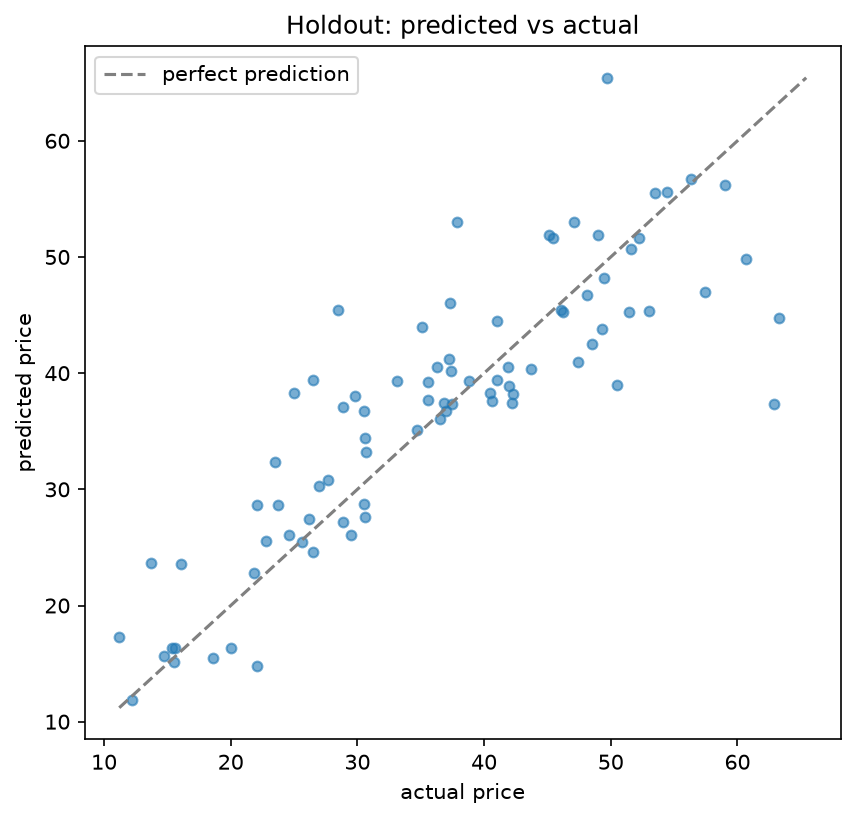

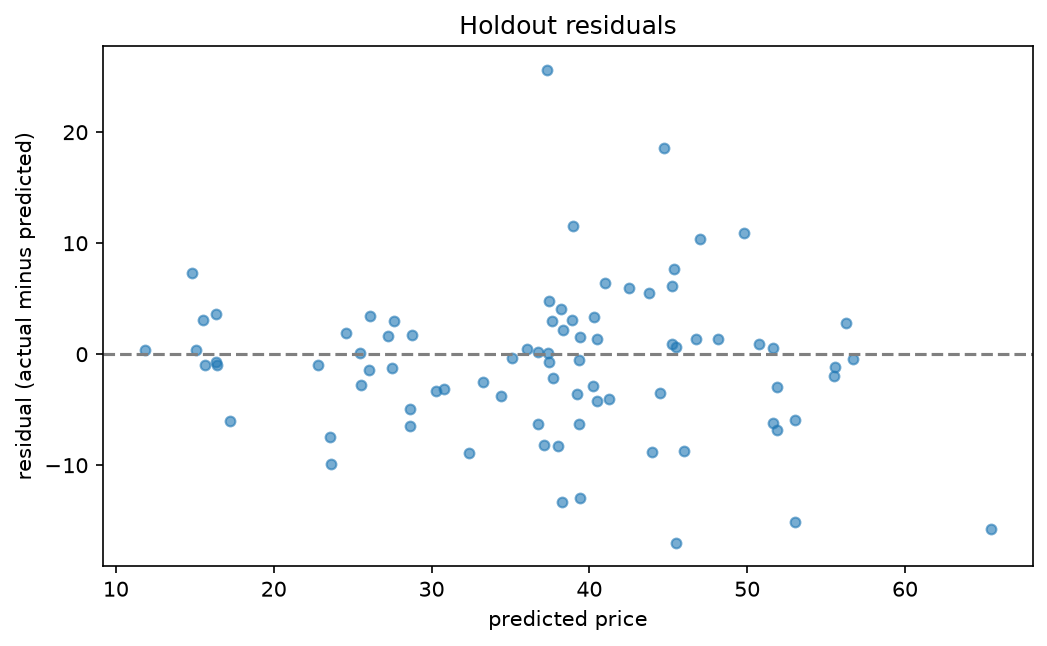

In [14]:
display(Image(str(config.REPORTS_DIR / "model_pred_vs_actual.png")))
display(Image(str(config.REPORTS_DIR / "model_residuals.png")))

Predictions follow the diagonal across most of the price range. Residuals are
spread around zero with no strong pattern against the fitted value. The largest
errors are at the top of the range, where predictions fall below the actual
value. The training data contains few expensive properties, so the fitted
relationship is dominated by the mid range.

## 9. Interpretation

The selected model is linear, so its coefficients can be read directly. They are
fitted on standardised features, so each coefficient is the change in price
associated with a one standard deviation change in that feature, and the
magnitudes are comparable across features.

In [15]:
artifact = joblib.load(config.MODELS_DIR / config.MODEL_FILENAME)
pipeline = artifact["point"]
coefficients = pd.Series(
    pipeline.named_steps["model"].coef_,
    index=pipeline.named_steps["features"].get_feature_names_out(),
).sort_values()
coefficients.round(2).to_frame("coefficient")

,coefficient
house_age_years,-9.43
log10_mrt_distance,-6.67
longitude,-0.03
n_convenience_stores,1.07
latitude,3.69
house_age_squared,6.91


`house_age_years` at -9.43 with `house_age_squared` at +6.91 is the age curve
from the EDA expressed as two coefficients. The negative linear term lowers
price as age increases, and the positive squared term turns the curve back up
for older properties. Neither number is meaningful on its own.

`log10_mrt_distance` at -6.67 is the largest single effect, consistent with the
EDA where it was the strongest correlate of price.

`longitude` at -0.03 is close to zero while `latitude` is +3.69. Longitude
overlaps heavily with MRT distance, so once distance is in the model there is
little left for longitude to explain. This is why coefficients of overlapping
predictors should not be read as the isolated effect of one predictor. Lasso
removing longitude in section 5 is the same effect seen from another angle.

These coefficients describe associations in transaction records from one
district between 2012 and 2013. They do not show that changing a feature would
change a price.

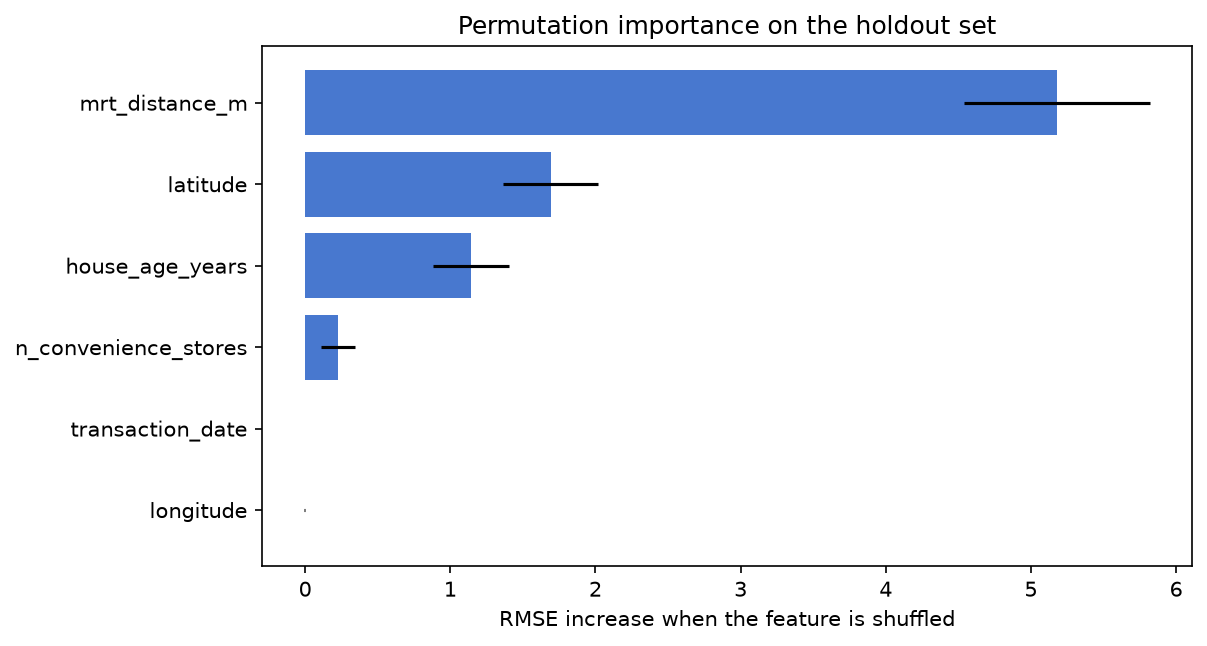

In [16]:
display(Image(str(config.REPORTS_DIR / "model_permutation_importance.png")))

Permutation importance measures the increase in holdout RMSE when one input
column is shuffled. It is computed on the raw input columns, before the
transforms, so it reports the contribution of each input the API receives rather
than of each derived feature. The ordering agrees with the coefficients.

## 10. Production decision and limitations

**Selected model.** Linear regression on log10 MRT distance, house age, house
age squared, number of convenience stores, latitude and longitude, with standard
scaling. The dataset holds 414 transactions: 331 were used to fit this model and
83 were held out. The artifact that ships is the one fitted on those 331 rows,
so the evaluated model and the served model are the same object.

**Reason.** Its cross-validated error is close enough to the best candidate that
the difference is not meaningful at this sample size, while it remains a readable
function of six inputs. It is cheap to retrain, cheap to serve, small to store,
and it can be explained to a non-technical stakeholder.

**Limitations.**

- 414 transactions from Sindian District, New Taipei City, recorded in 2012 and
  2013. The model describes that market at that time. Applying it to another
  district or to current prices is extrapolation.
- The holdout is 83 rows, so metrics computed on it carry meaningful
  uncertainty.
- Properties above roughly 60 units are underrepresented and predictions there
  are biased low.
- `transaction_date` is excluded, so the model has no mechanism for market
  drift. Accuracy will degrade as the market moves away from 2013.
- The prediction interval has a fixed width for every property, so it does not
  widen for inputs the model finds unusual. See the appendix.
- The interval's measured coverage comes from the same 83 holdout rows used
  throughout this notebook, so it is exploratory rather than validated.
- The polynomial age term extrapolates without bound, so the service refuses to
  predict outside the range the model was fitted on rather than returning a
  number with no support behind it.

**Before running this against a live market.** Current transaction data with a
defined refresh cadence; a time or market-index feature that is valid at
prediction time, to replace the excluded transaction date; monitoring of
prediction error against realised sale prices; and a retraining trigger tied to
that monitoring.

## Appendix: prediction intervals

A point estimate on its own invites false precision, so the API returns a range
alongside it. This is a secondary feature and takes no part in model selection.

### The first implementation, and why it was replaced

The interval was originally produced by two gradient boosting models fitted with
a quantile loss at the 5th and 95th percentiles. Reviewing it against the holdout
showed two problems.

Coverage was 82% against a 90% design target, so the interval was too narrow.

More seriously, the bounds came from a different model than the point estimate.
The linear model and the boosting models do not agree, so the estimate did not
sit centrally inside its own interval. For one example house the estimate was
47.2 while the two bounds were 41.8 and 67.0, whose midpoint is 54.4. The
reported number sat near the bottom of a range built around a different model's
opinion. (Those three figures come from the replaced implementation and are
recorded here for the comparison; they are not reproducible from the cells
below, which run the current one.)

### The current implementation

The interval is now built from the selected model's own errors. Predictions are
made out of fold on the training data, the residuals are collected, and the 5th
and 95th percentiles of those residuals become fixed offsets applied to any
prediction.

Out-of-fold residuals matter here: an in-sample residual understates the error,
because the model has already seen that row.

In [17]:
bounds = artifact["residual_bounds"]
print(f"residual 5th percentile:  {bounds['lower']:+.2f}")
print(f"residual 95th percentile: {bounds['upper']:+.2f}")
print(f"interval width: {bounds['upper'] - bounds['lower']:.2f}")

residual 5th percentile:  -10.57
residual 95th percentile: +11.76
interval width: 22.33


In [18]:
example = pd.DataFrame([{
    "house_age_years": 10.0,
    "mrt_distance_m": 250.0,
    "n_convenience_stores": 6,
    "latitude": 24.975,
    "longitude": 121.540,
}])
point = float(artifact["point"].predict(example)[0])
print(f"point estimate: {point:.1f} (10,000 TWD per ping)")
print(f"interval:       {point + bounds['lower']:.1f} to {point + bounds['upper']:.1f}")
print(f"observed holdout coverage: {results['interval_coverage']:.0%}")

point estimate: 47.2 (10,000 TWD per ping)
interval:       36.6 to 58.9
observed holdout coverage: 92%


The range is derived from the residual distribution of the selected model, so
both halves of the answer now come from the same place. The offsets are not
symmetric, -10.57 against +11.76, because the model's errors are not symmetric,
so the range is not centred on the estimate.

Coverage measured on the holdout is 92% against the 90% target. That figure
should be read carefully. The holdout was already inspected during this work, so
this is exploratory coverage on a set that is no longer untouched, not a
validated guarantee. It is 83 rows, which carries substantial uncertainty of its
own. A trustworthy coverage figure would need a separate set that has never been
looked at.

**Known limitation, not scheduled for change here.** The offsets are constant, so
every property receives the same interval width. A property the model finds
unusual deserves a wider range than a typical one, and this design does not
provide that. It is recorded as a limitation rather than worked around.

Removing the two gradient boosting models also made the artifact smaller and the
serving path simpler: one fitted pipeline and two numbers, instead of three
fitted pipelines.

**How serving handles inputs outside the fitted range.** The API does not
extrapolate. If any input falls outside the range the model was fitted on, it
returns 422 with an `outside_model_support` error naming the offending fields
and their supported ranges, and it does not clip the input to the nearest
supported value. The earlier example of a 95-year-old property 9 km from a
station is refused rather than answered, because the polynomial age term makes
any answer there unsupported.